In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("MNE version:", mne.__version__)

MNE version: 1.13.2


In [2]:
DATA_ROOT = Path(r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148")

vhdr_files = sorted(DATA_ROOT.glob(
    "sub-01/ses-session1/eeg/*task-memory_eeg.vhdr"
))

vhdr_files

[WindowsPath('C:/Users/Sanjeev/OneDrive/Desktop/Brain ID/EEG/ds004148/sub-01/ses-session1/eeg/sub-01_ses-session1_task-memory_eeg.vhdr')]

In [3]:
vhdr_file = vhdr_files[0]

print(vhdr_file)
print(vhdr_file.exists())

C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr
True


In [4]:
raw = mne.io.read_raw_brainvision(
    vhdr_file,
    preload=True
)

print(raw)


Extracting parameters from C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 61 x 150000 (300.0 s), ~69.9 MiB, data loaded>


In [5]:
print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")
print("Number of channels:", len(raw.ch_names))

Sampling frequency: 500.0
Number of channels: 61
Duration: 299.998 seconds
Number of channels: 61


In [6]:
print(raw.ch_names)

['Fp1', 'AF3', 'AF7', 'Fz', 'F1', 'F3', 'F5', 'F7', 'FC1', 'FC3', 'FC5', 'FT7', 'Cz', 'C1', 'C3', 'C5', 'T7', 'CP1', 'CP3', 'CP5', 'TP7', 'TP9', 'Pz', 'P1', 'P3', 'P5', 'P7', 'PO3', 'PO7', 'Oz', 'O1', 'Fpz', 'Fp2', 'AF4', 'AF8', 'F2', 'F4', 'F6', 'F8', 'FC2', 'FC4', 'FC6', 'FT8', 'C2', 'C4', 'C6', 'T8', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P2', 'P4', 'P6', 'P8', 'POz', 'PO4', 'PO8', 'O2']


In [7]:
target_channels = ["Fp1", "Fp2", "Fz"]

for ch in target_channels:
    print(ch, "→", ch in raw.ch_names)

Fp1 → True
Fp2 → True
Fz → True


In [8]:
raw.info

<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, AF3, AF7, Fz, F1, F3, F5, F7, FC1, FC3, FC5, FT7, Cz, C1, ...
 chs: 61 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 61
 projs: []
 sfreq: 500.0 Hz
>

In [10]:
print(raw.get_channel_types())
print(raw.info["line_freq"])

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
None


In [11]:
print(raw.annotations)

<Annotations | 151 segments: Stimulus/S 66 (1), SyncStatus/Sync Off (150)>


In [12]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:")
print(event_id)

print("\nNumber of events:", len(events))
print("\nFirst events:")
print(events[:20])

Used Annotations descriptions: ['Stimulus/S 66', 'SyncStatus/Sync Off']
Event IDs:
{'Stimulus/S 66': 66, 'SyncStatus/Sync Off': 10001}

Number of events: 151

First events:
[[    0     0    66]
 [  286     0 10001]
 [ 1286     0 10001]
 [ 2286     0 10001]
 [ 3286     0 10001]
 [ 4286     0 10001]
 [ 5286     0 10001]
 [ 6286     0 10001]
 [ 7286     0 10001]
 [ 8286     0 10001]
 [ 9286     0 10001]
 [10286     0 10001]
 [11286     0 10001]
 [12286     0 10001]
 [13286     0 10001]
 [14286     0 10001]
 [15286     0 10001]
 [16286     0 10001]
 [17286     0 10001]
 [18286     0 10001]]


In [23]:
print(raw_3ch)
print("\nSampling frequency:", raw_3ch.info["sfreq"])
print("Duration:", raw_3ch.times[-1], "seconds")
print("Channels:", raw_3ch.ch_names)

<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 3 x 150000 (300.0 s), ~3.4 MiB, data loaded>

Sampling frequency: 500.0
Duration: 299.998 seconds
Channels: ['Fp1', 'Fp2', 'Fz']


In [24]:
data = raw_3ch.get_data()

print("Shape:", data.shape)
print("Minimum:", data.min())
print("Maximum:", data.max())
print("Mean:", data.mean())
print("Std:", data.std())

Shape: (3, 150000)
Minimum: -0.0001318000030517578
Maximum: 0.0002508999938964844
Mean: 2.5260711554028523e-05
Std: 3.637730347213846e-05


In [25]:
data_uv = data * 1e6

for ch, signal in zip(raw_3ch.ch_names, data_uv):
    print(
        f"{ch}: "
        f"min={signal.min():.2f} µV, "
        f"max={signal.max():.2f} µV, "
        f"mean={signal.mean():.2f} µV, "
        f"std={signal.std():.2f} µV"
    )

Fp1: min=-131.80 µV, max=238.90 µV, mean=2.80 µV, std=40.97 µV
Fp2: min=-97.10 µV, max=250.90 µV, mean=39.59 µV, std=35.83 µV
Fz: min=-10.80 µV, max=80.20 µV, mean=33.40 µV, std=15.21 µV


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


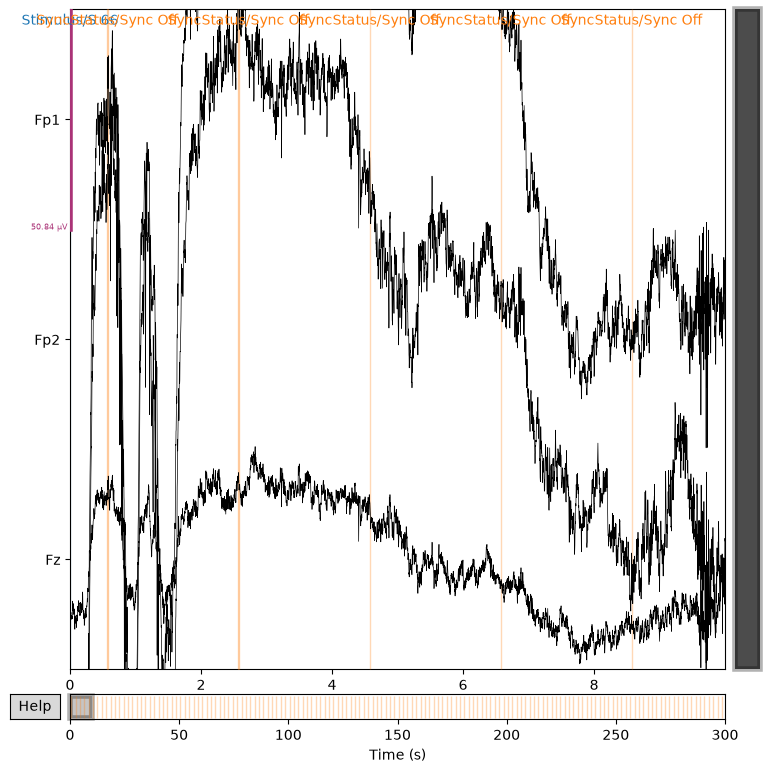

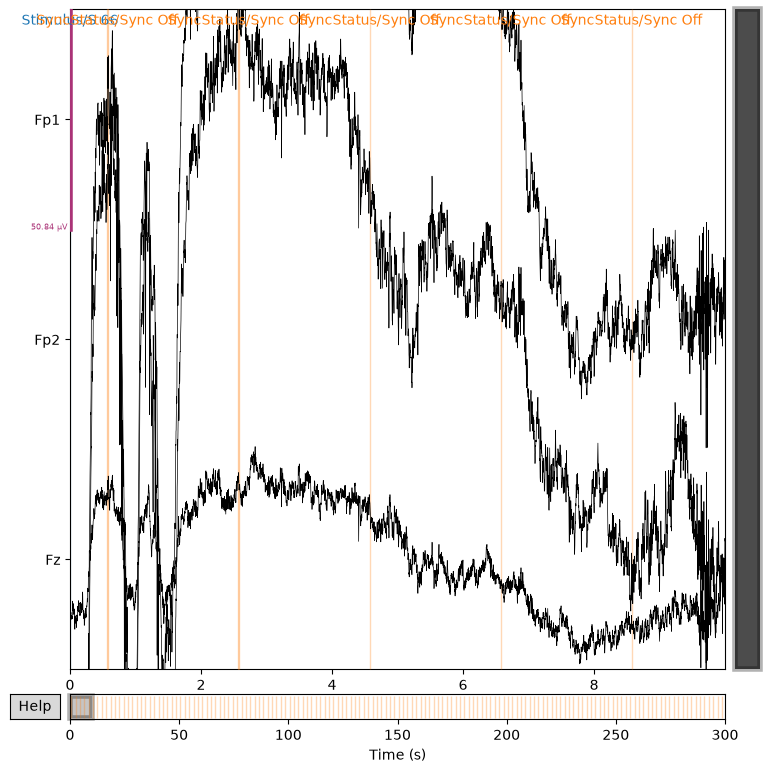

In [ ]:
raw_3ch = raw.copy().pick(["Fp1", "Fp2", "Fz"])

raw_3ch.plot(
    duration=10,
    n_channels=3,
    scalings="auto",
    title="Fp1, Fp2, Fz — Raw EEG"
)



For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


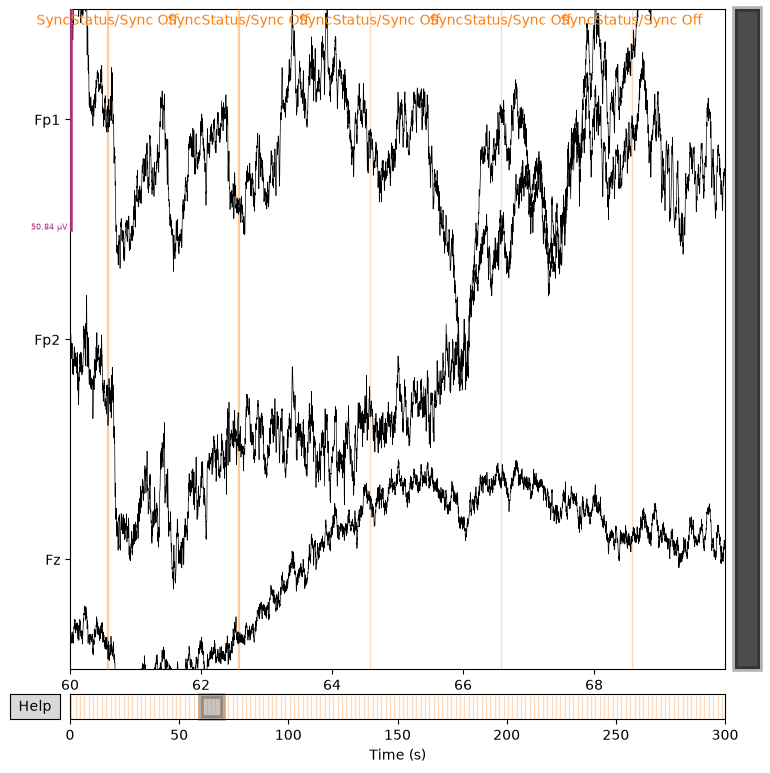

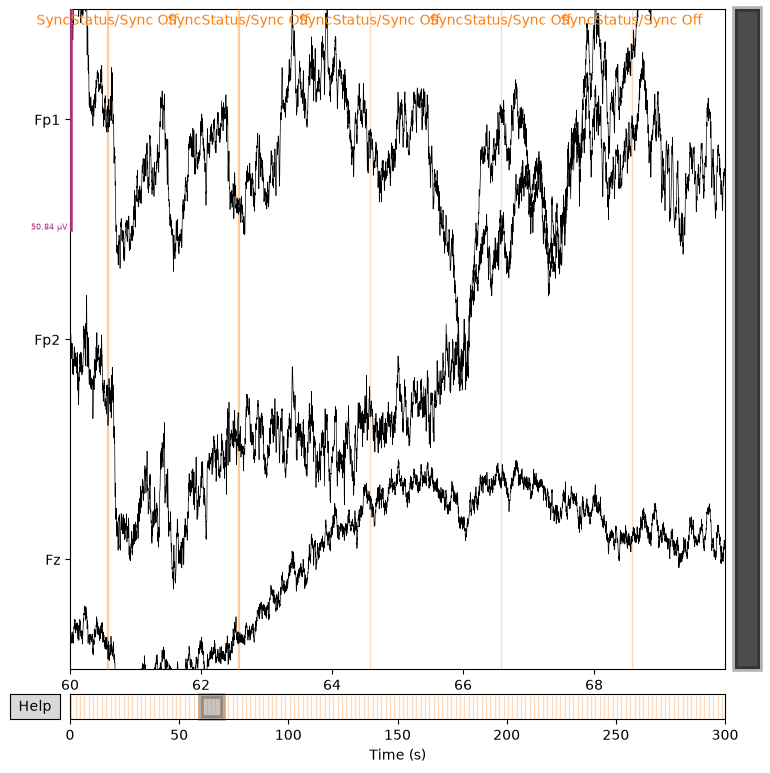

In [28]:
raw_3ch.plot(
    duration=10,
    start=60,
    n_channels=3,
    scalings="auto",
    title="Raw EEG — 60 to 70 seconds"
)

**Inspect one complete recording**

In [35]:
event_rows = []

for sample, _, event_code in events:
    event_rows.append({
        "sample": sample,
        "time_sec": sample / raw.info["sfreq"],
        "event_code": event_code
    })

events_df = pd.DataFrame(event_rows)

events_df.head(30)

,sample,time_sec,event_code
0,0,0.000,66
1,286,0.572,10001
2,1286,2.572,10001
3,2286,4.572,10001
4,3286,6.572,10001
5,4286,8.572,10001
6,5286,10.572,10001
7,6286,12.572,10001
8,7286,14.572,10001
9,8286,16.572,10001


In [36]:
events_df["event_name"] = events_df["event_code"].map(
    {v: k for k, v in event_id.items()}
)

events_df.head(30)

,sample,time_sec,event_code,event_name
0,0,0.000,66,Stimulus/S 66
1,286,0.572,10001,SyncStatus/Sync Off
2,1286,2.572,10001,SyncStatus/Sync Off
3,2286,4.572,10001,SyncStatus/Sync Off
4,3286,6.572,10001,SyncStatus/Sync Off
5,4286,8.572,10001,SyncStatus/Sync Off
6,5286,10.572,10001,SyncStatus/Sync Off
7,6286,12.572,10001,SyncStatus/Sync Off
8,7286,14.572,10001,SyncStatus/Sync Off
9,8286,16.572,10001,SyncStatus/Sync Off


In [37]:
data_uv = raw_3ch.get_data() * 1e6

for ch, signal in zip(raw_3ch.ch_names, data_uv):
    print(
        f"{ch}: "
        f"min={signal.min():.2f} µV, "
        f"max={signal.max():.2f} µV, "
        f"mean={signal.mean():.2f} µV, "
        f"std={signal.std():.2f} µV"
    )

Fp1: min=-131.80 µV, max=238.90 µV, mean=2.80 µV, std=40.97 µV
Fp2: min=-97.10 µV, max=250.90 µV, mean=39.59 µV, std=35.83 µV
Fz: min=-10.80 µV, max=80.20 µV, mean=33.40 µV, std=15.21 µV


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


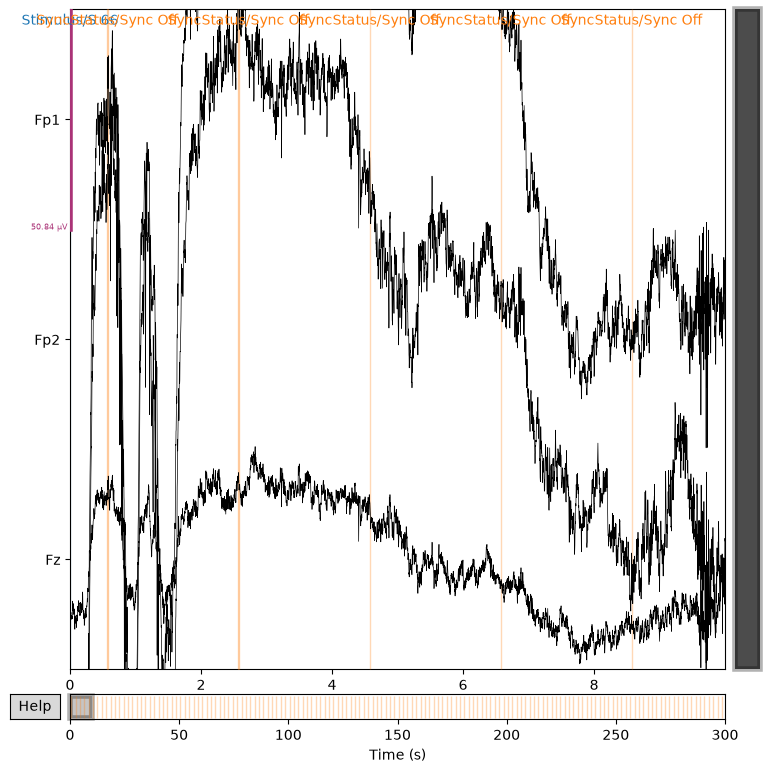

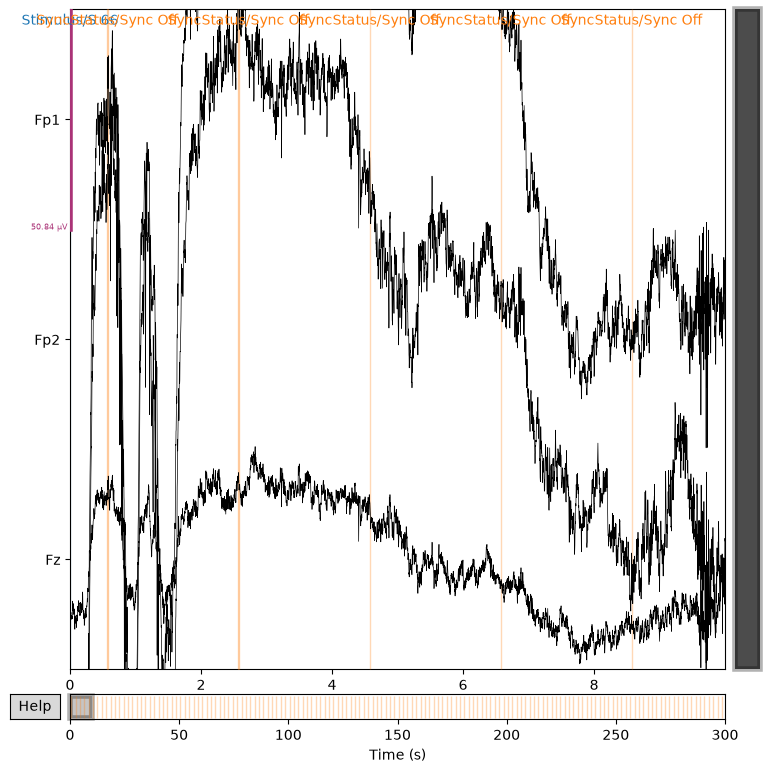

In [38]:
raw_3ch.plot(
    duration=10,
    start=0,
    n_channels=3,
    scalings="auto",
    title="Raw EEG — 0–10 s"
)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


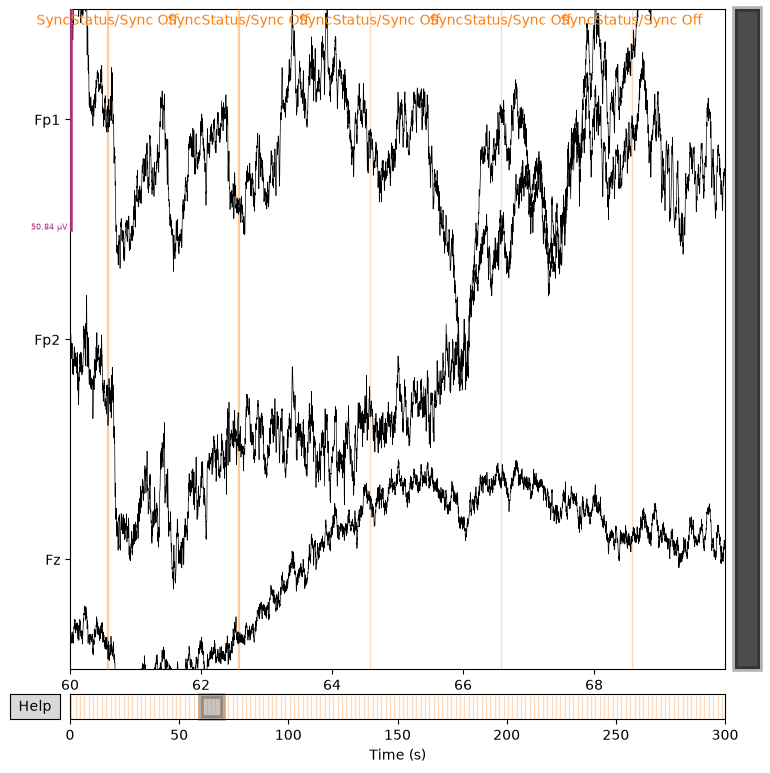

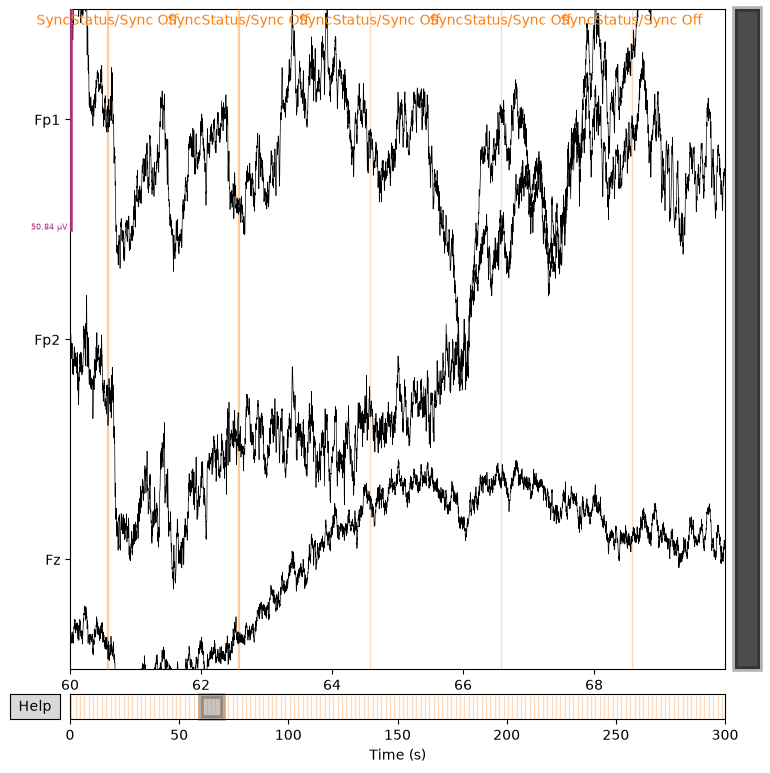

In [39]:
raw_3ch.plot(
    duration=10,
    start=60,
    n_channels=3,
    scalings="auto",
    title="Raw EEG — 60–70 s"
)